# Cal Target SR Analysis\n\nCompare Native-2x, SAA, and SAA+IBP super-resolution results on the ISO 12233 calibration target.\n\n**ROI 1 — Horizontal bars:** vertical cross-section (at column 2700 HR) through the horizontal bar groups on the right side of the chart. Shows whether SR resolves higher spatial frequencies.\n\n**ROI 2 — Slanted edge MTF:** one edge of a thick diagonal line is isolated and used for slanted-edge MTF measurement, comparing edge sharpness across methods.

In [94]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import zoom as ndi_zoom
from scipy.optimize import curve_fit

%matplotlib inline
plt.rcParams['figure.dpi'] = 130

# --- Pick the session folder ---
SESSION = 'tilt0.14128_settletime50ms'
SR_DIR  = os.path.join(SESSION, 'sr_output')

# Load images and rotate 180° to correct orientation
lr_mean   = np.rot90(np.array(Image.open(os.path.join(SR_DIR, 'LR_mean.png')), dtype=np.float64), 0)
native_2x = np.rot90(np.array(Image.open(os.path.join(SR_DIR, 'native_2x.png')), dtype=np.float64), 0)
saa       = np.rot90(np.array(Image.open(os.path.join(SR_DIR, 'SAA.png')), dtype=np.float64), 0)
saa_ibp   = np.rot90(np.array(Image.open(os.path.join(SR_DIR, 'SAA_IBP.png')), dtype=np.float64), 0)

hr_images = {
    'Native-2x': native_2x,
    'SAA':       saa,
    'SAA+IBP':   saa_ibp,
}

print(f'LR shape : {lr_mean.shape}')
print(f'HR shape : {native_2x.shape}')

LR shape : (1536, 2048)
HR shape : (3072, 4096)


## ROI 1 — Horizontal bar resolution\n\nVertical cross-section at column 2700 (HR) through the horizontal bar groups on the right side of the chart. The profile runs along the row axis, cutting across the bars.

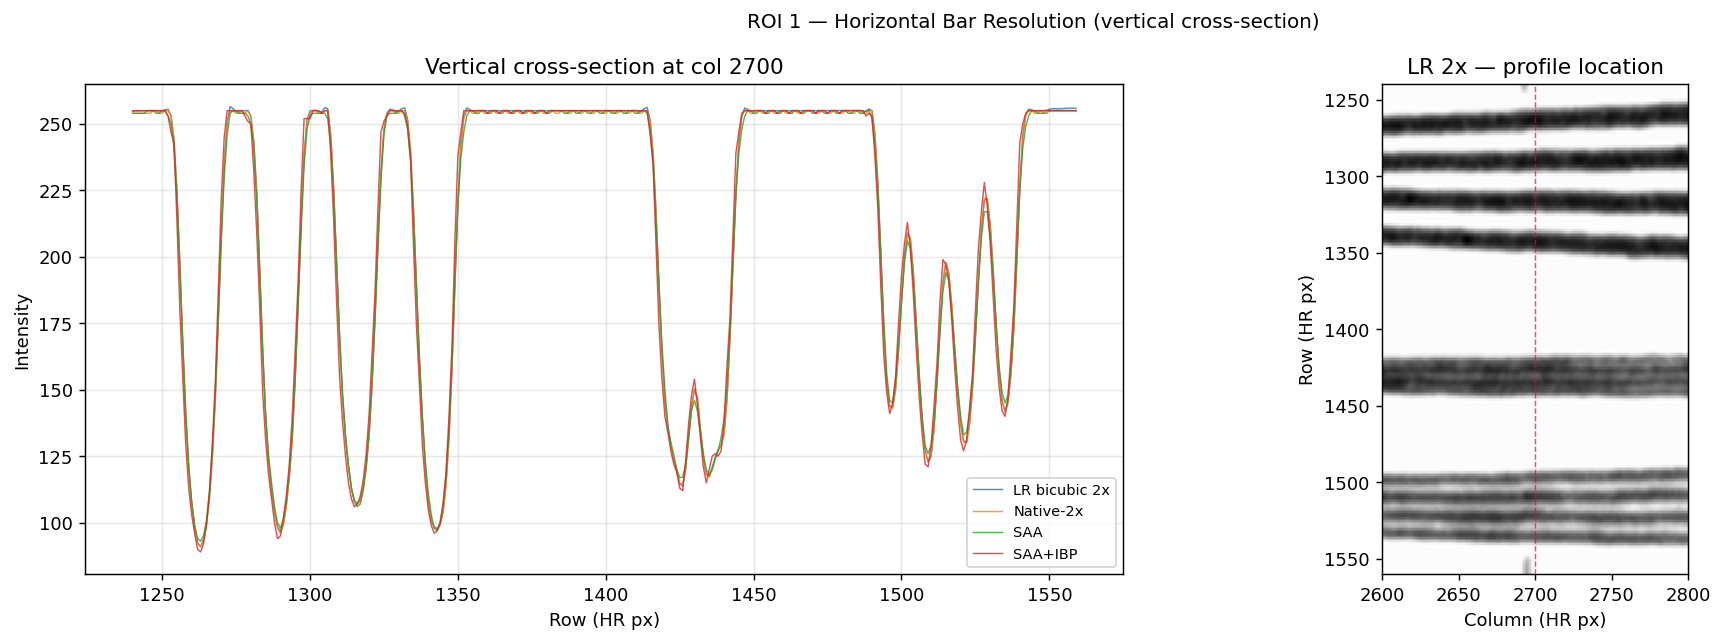

In [95]:
# ROI 1: vertical cross-section through horizontal bars on the right side
# Column 2700 in HR coords (= col 1350 in LR), rows spanning the bar groups
PROFILE_COL_HR = 2700
ROI1_ROWS_HR   = slice(1240, 1560)   # rows 620–780 in LR, scaled to HR

lr_2x  = ndi_zoom(lr_mean, 2, order=3)
titles = ['LR bicubic 2x', 'Native-2x', 'SAA', 'SAA+IBP']
imgs   = [lr_2x, native_2x, saa, saa_ibp]
colors = ['C0', 'C1', 'C2', 'C3']

rows_hr = np.arange(ROI1_ROWS_HR.start, ROI1_ROWS_HR.stop)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all profiles overlaid
ax = axes[0]
for title, img, c in zip(titles, imgs, colors):
    profile = img[ROI1_ROWS_HR, PROFILE_COL_HR]
    ax.plot(rows_hr, profile, lw=0.8, alpha=0.8, label=title, color=c)
ax.set_xlabel('Row (HR px)')
ax.set_ylabel('Intensity')
ax.set_title(f'Vertical cross-section at col {PROFILE_COL_HR}')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: zoomed image strips showing the column location
ax = axes[1]
# Show a narrow horizontal band around the profile column for context
strip_w = 200
col_lo = PROFILE_COL_HR - strip_w // 2
col_hi = PROFILE_COL_HR + strip_w // 2
ax.imshow(lr_2x[ROI1_ROWS_HR, col_lo:col_hi], cmap='gray',
          interpolation='nearest', extent=[col_lo, col_hi, ROI1_ROWS_HR.stop, ROI1_ROWS_HR.start])
ax.axvline(PROFILE_COL_HR, color='r', lw=0.8, ls='--', alpha=0.7)
ax.set_title('LR 2x — profile location')
ax.set_xlabel('Column (HR px)')
ax.set_ylabel('Row (HR px)')

plt.suptitle('ROI 1 — Horizontal Bar Resolution (vertical cross-section)', fontsize=11)
plt.tight_layout()
plt.show()

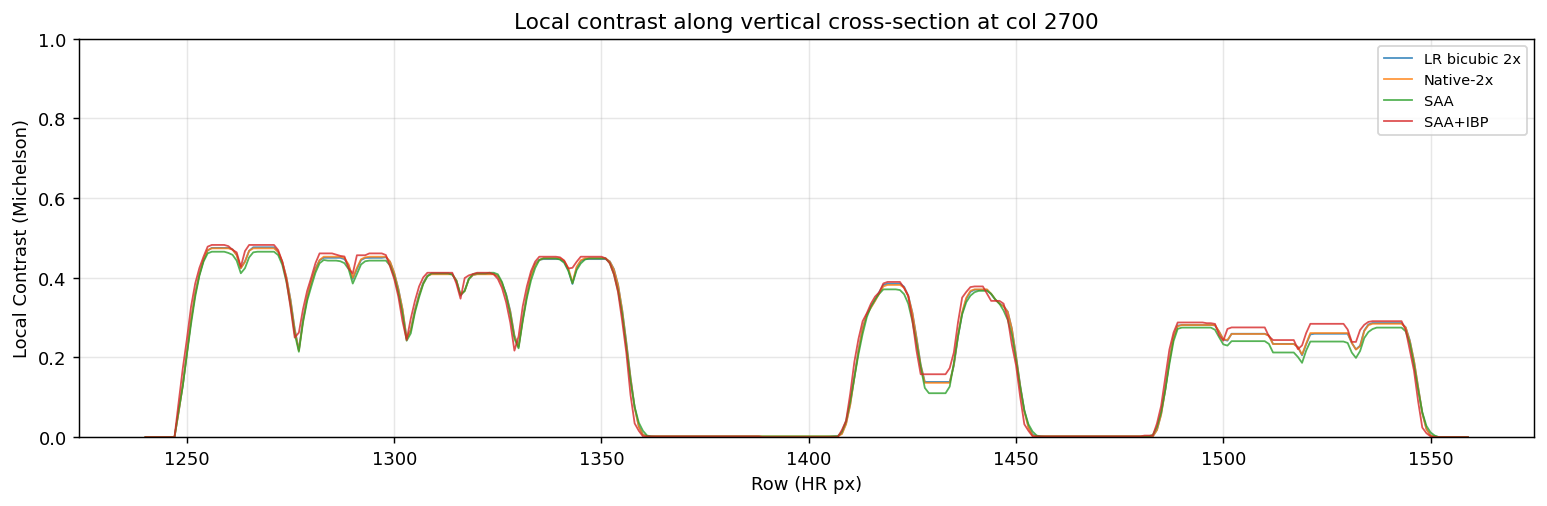

In [96]:
# Contrast (modulation) along the vertical cross-section

def local_contrast(profile, window=20):
    """Compute (max - min) / (max + min) in a sliding window."""
    n = len(profile)
    contrast = np.zeros(n)
    hw = window // 2
    for i in range(hw, n - hw):
        seg = profile[i - hw:i + hw]
        mn, mx = seg.min(), seg.max()
        contrast[i] = (mx - mn) / (mx + mn + 1e-9)
    return contrast

fig, ax = plt.subplots(figsize=(12, 4))
for title, img, c in zip(titles, imgs, colors):
    profile = img[ROI1_ROWS_HR, PROFILE_COL_HR]
    ct = local_contrast(profile, window=16)
    ax.plot(rows_hr, ct, lw=1, alpha=0.8, label=title, color=c)

ax.set_ylabel('Local Contrast (Michelson)')
ax.set_xlabel('Row (HR px)')
ax.set_title(f'Local contrast along vertical cross-section at col {PROFILE_COL_HR}')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ROI 2 — Slanted Edge MTF\n\nIsolate one edge of the thick diagonal line (lower-right, going from centre toward the corner). The chart has a slight tilt (~0.14°), providing sub-pixel sampling across the edge. We fit the Edge Spread Function (ESF), differentiate to get the Line Spread Function (LSF), and FFT to obtain the MTF.\n\nOnly one black→white transition is used (the left edge of the dark line, where pixel values go from dark to bright as we scan left to right).

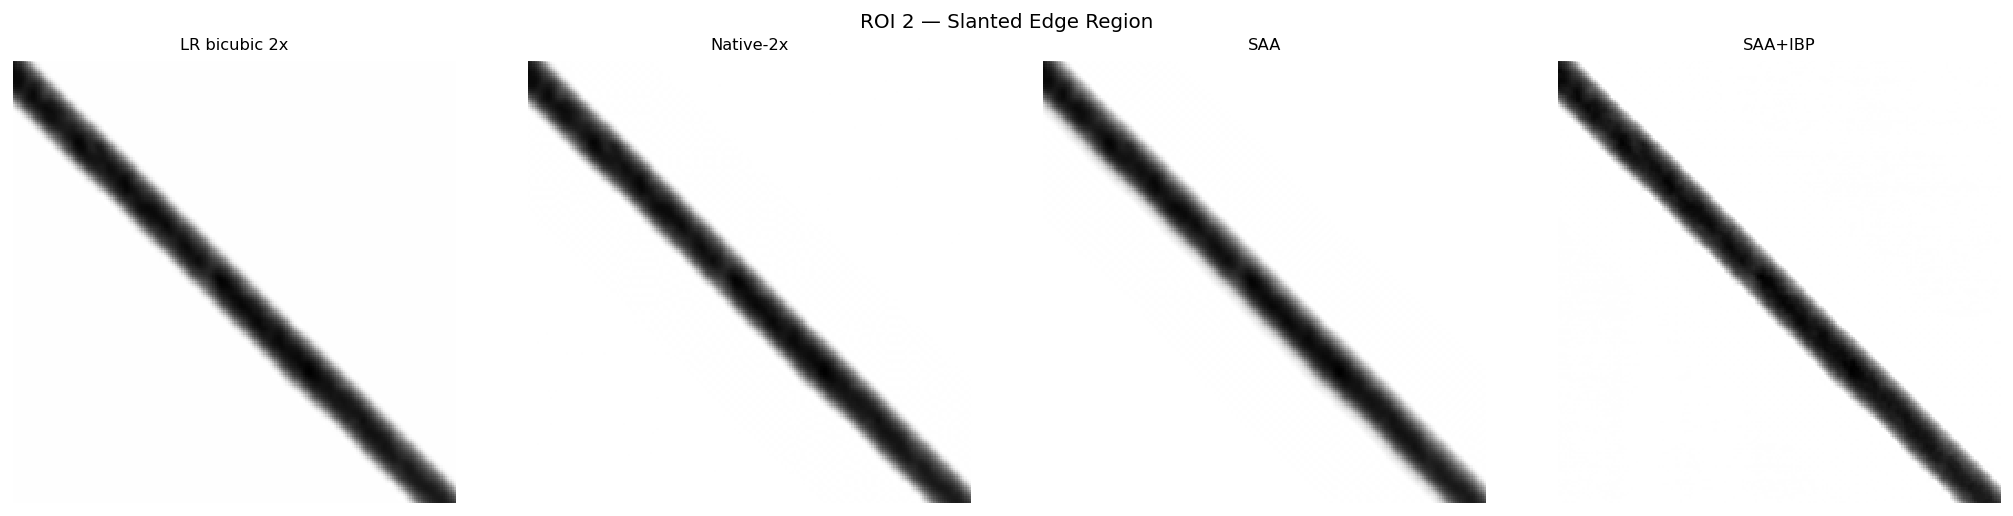

In [97]:
# ROI 2 coordinates (in LR pixels) — thick diagonal line, lower-right
# Clean section with white on both sides, away from labels/bars
ROI2_LR = (slice(950, 1050), slice(1280, 1380))
ROI2_HR = (slice(ROI2_LR[0].start * 2, ROI2_LR[0].stop * 2),
           slice(ROI2_LR[1].start * 2, ROI2_LR[1].stop * 2))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, title, img in zip(axes, titles, imgs):
    roi = img[ROI2_HR]
    ax.imshow(roi, cmap='gray', interpolation='nearest')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.suptitle('ROI 2 — Slanted Edge Region', fontsize=11)
plt.tight_layout()
plt.show()

In [98]:
def slanted_edge_esf(roi, side='left'):
    """Extract the oversampled ESF from ONE edge of a thick line at any angle.

    Steps:
      1. Detect edge pixels via Sobel gradient.
      2. Fit a centre-line to all edge pixels.
      3. Split edge pixels into two clusters (the two sides of the line)
         and re-fit a line to only the chosen cluster.
      4. Project every pixel onto the perpendicular axis of that single edge.
      5. Crop to the monotonic region of the transition and bin into a 4x
         oversampled ESF.

    Parameters
    ----------
    roi  : 2-D array
    side : 'left'  — use the edge with more negative perpendicular distance
           'right' — use the edge with more positive perpendicular distance

    Returns
    -------
    esf_x, esf_y, edge_angle_deg
    """
    from scipy.ndimage import gaussian_filter, sobel

    # 1. Gradient magnitude
    smooth = gaussian_filter(roi.astype(np.float64), sigma=1.5)
    gy = sobel(smooth, axis=0)
    gx = sobel(smooth, axis=1)
    mag = np.sqrt(gx**2 + gy**2)

    thresh = np.percentile(mag, 85)
    rs, cs = np.where(mag > thresh)
    if len(rs) < 20:
        raise RuntimeError('Too few edge pixels detected')

    # 2. Fit a centre-line to ALL edge pixels
    row_span = rs.max() - rs.min()
    col_span = cs.max() - cs.min()
    use_row_as_x = (row_span >= col_span)

    if use_row_as_x:
        coeffs_centre = np.polyfit(rs, cs, 1)
        m_c = coeffs_centre[0]
        norm_c = np.sqrt(1 + m_c**2)
        edge_dist = (cs - m_c * rs - coeffs_centre[1]) / norm_c
    else:
        coeffs_centre = np.polyfit(cs, rs, 1)
        m_c = coeffs_centre[0]
        norm_c = np.sqrt(1 + m_c**2)
        edge_dist = (rs - m_c * cs - coeffs_centre[1]) / norm_c

    # 3. Split into two clusters and pick one
    if side == 'left':
        cluster_mask = edge_dist < 0
    else:
        cluster_mask = edge_dist > 0

    rs_sel, cs_sel = rs[cluster_mask], cs[cluster_mask]
    if len(rs_sel) < 10:
        raise RuntimeError(f'Too few edge pixels on {side} side')

    # Re-fit line to the selected cluster only
    if use_row_as_x:
        coeffs = np.polyfit(rs_sel, cs_sel, 1)
        m = coeffs[0]
        norm = np.sqrt(1 + m**2)
        edge_angle = np.degrees(np.arctan2(1, m))
        nrows, ncols = roi.shape
        rr, cc = np.mgrid[:nrows, :ncols]
        dist = (cc - m * rr - coeffs[1]) / norm
    else:
        coeffs = np.polyfit(cs_sel, rs_sel, 1)
        m = coeffs[0]
        norm = np.sqrt(1 + m**2)
        edge_angle = np.degrees(np.arctan2(m, 1))
        nrows, ncols = roi.shape
        rr, cc = np.mgrid[:nrows, :ncols]
        dist = (rr - m * cc - coeffs[1]) / norm

    print(f'  Edge angle: {edge_angle:.1f} deg, '
          f'{len(rs_sel)}/{len(rs)} edge pixels ({side} side)')

    # 4. Flatten and keep only the monotonic region around this single edge
    flat_dist = dist.ravel()
    flat_val  = roi.ravel().astype(np.float64)

    # Band: generous flat plateaus on both sides for good frequency resolution
    # but not so wide as to include the second edge (~8 px away)
    keep = (flat_dist > -8) & (flat_dist < 10)
    flat_dist = flat_dist[keep]
    flat_val  = flat_val[keep]

    # 5. Bin into 4x oversampled ESF
    oversample = 4
    bin_width  = 1.0 / oversample
    bins = np.arange(flat_dist.min(), flat_dist.max() + bin_width, bin_width)
    esf_x = 0.5 * (bins[:-1] + bins[1:])
    esf_y = np.empty(len(esf_x))
    esf_y[:] = np.nan
    for i in range(len(esf_x)):
        mask = (flat_dist >= bins[i]) & (flat_dist < bins[i + 1])
        if mask.sum() > 0:
            esf_y[i] = flat_val[mask].mean()

    valid = ~np.isnan(esf_y)
    if valid.sum() > 2:
        esf_y = np.interp(esf_x, esf_x[valid], esf_y[valid])

    # Ensure ESF is monotonically increasing (bright on the right)
    if esf_y[-1] < esf_y[0]:
        esf_x = -esf_x[::-1]
        esf_y = esf_y[::-1]

    return esf_x, esf_y, edge_angle


def esf_to_mtf(esf_x, esf_y):
    """ESF -> LSF (derivative) -> MTF (|FFT|), all normalised."""
    lsf = np.gradient(esf_y, esf_x)

    window = np.hanning(len(lsf))
    lsf_w  = lsf * window

    n   = len(lsf_w)
    mtf = np.abs(np.fft.fft(lsf_w))
    mtf = mtf[:n // 2]
    if mtf[0] > 0:
        mtf /= mtf[0]

    dx   = np.mean(np.diff(esf_x))
    freq = np.fft.fftfreq(n, d=dx)[:n // 2]

    return freq, mtf, lsf

print('Slanted-edge MTF functions defined.')

Slanted-edge MTF functions defined.


In [99]:
# Compute ESF and MTF for each method using one edge of the diagonal line.
# The ROI contains a thick dark line — we isolate the LEFT edge (white→black).

results = {}
for title, img in zip(titles, imgs):
    print(f'\n{title}:')
    roi = img[ROI2_HR]
    esf_x, esf_y, angle = slanted_edge_esf(roi, side='left')
    freq, mtf, lsf = esf_to_mtf(esf_x, esf_y)
    results[title] = {
        'esf_x': esf_x, 'esf_y': esf_y,
        'freq': freq, 'mtf': mtf, 'lsf': lsf,
        'angle': angle,
    }

print('\nDone.')


LR bicubic 2x:
  Edge angle: 45.1 deg, 2845/6000 edge pixels (left side)

Native-2x:
  Edge angle: 45.1 deg, 2846/6000 edge pixels (left side)

SAA:
  Edge angle: 45.1 deg, 2857/6000 edge pixels (left side)

SAA+IBP:
  Edge angle: 45.2 deg, 2861/6000 edge pixels (left side)

Done.


In [ ]:
# --- Plot ROI crop, ESF, and MTF comparison ---

SENSOR_PITCH_MM = 3.45e-3        # 3.45 um sensor pixel
HR_PITCH_MM     = SENSOR_PITCH_MM / 2  # 1.725 um per HR pixel (2x upsample)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROI crop showing the single edge used
ax = axes[0]
roi_show = native_2x[ROI2_HR]
ax.imshow(roi_show, cmap='gray', interpolation='nearest')
from scipy.ndimage import gaussian_filter, sobel
smooth = gaussian_filter(roi_show.astype(np.float64), sigma=1.5)
gy = sobel(smooth, axis=0)
gx = sobel(smooth, axis=1)
mag = np.sqrt(gx**2 + gy**2)
thresh = np.percentile(mag, 85)
rs, cs = np.where(mag > thresh)
coeffs_c = np.polyfit(rs, cs, 1)
m_c, b_c = coeffs_c
norm_c = np.sqrt(1 + m_c**2)
edge_dist = (cs - m_c * rs - b_c) / norm_c
rs_sel = rs[edge_dist < 0]
cs_sel = cs[edge_dist < 0]
coeffs_edge = np.polyfit(rs_sel, cs_sel, 1)
m_e, b_e = coeffs_edge
row_range = np.array([0, roi_show.shape[0] - 1])
edge_col = m_e * row_range + b_e
ax.plot(edge_col, row_range, 'r-', lw=1.5, label='Edge')
norm_e = np.sqrt(1 + m_e**2)
for d, ls in [(-8, '--'), (10, '--')]:
    band_col = edge_col + d * norm_e
    ax.plot(band_col, row_range, 'r', ls=ls, lw=0.8, alpha=0.6)
ax.set_title('ROI — single edge used', fontsize=9)
ax.legend(fontsize=7, loc='lower right')
ax.axis('off')

# ESF
ax = axes[1]
for title, c in zip(titles, colors):
    r = results[title]
    ax.plot(r['esf_x'], r['esf_y'], lw=1.2, alpha=0.8, color=c, label=title)
ax.set_xlabel('Distance from edge (px)')
ax.set_ylabel('Intensity')
ax.set_title('Edge Spread Function (ESF)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# MTF — frequencies in cycles/mm using HR pixel pitch
ax = axes[2]
nyquist_cpmm = 1.0 / (2.0 * HR_PITCH_MM)
for title, c in zip(titles, colors):
    r = results[title]
    freq_cpmm = r['freq'] / HR_PITCH_MM  # cycles/HR-pixel -> cycles/mm
    mtf = r['mtf']
    mask = (freq_cpmm > 0) & (freq_cpmm <= nyquist_cpmm)
    ax.plot(freq_cpmm[mask], mtf[mask], lw=1.5, alpha=0.8, color=c, label=title)

ax.axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5, label='MTF50')
ax.axhline(0.1, color='gray', ls=':', lw=0.8, alpha=0.5, label='MTF10')
ax.set_xlabel('Spatial frequency (cycles/mm)')
ax.set_ylabel('MTF')
ax.set_title('Modulation Transfer Function')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlim(0, nyquist_cpmm)
ax.grid(True, alpha=0.3)

plt.suptitle('Slanted Edge MTF', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# --- MTF summary table ---

def mtf_at_fraction(freq, mtf, fraction):
    """Find the spatial frequency where MTF crosses a given fraction."""
    above = mtf >= fraction
    if not above.any() or above.all():
        return np.nan
    idx = np.where(np.diff(above.astype(int)) == -1)[0]
    if len(idx) == 0:
        return np.nan
    i = idx[0]
    f0, f1 = freq[i], freq[i + 1]
    m0, m1 = mtf[i], mtf[i + 1]
    if abs(m1 - m0) < 1e-12:
        return f0
    return f0 + (fraction - m0) * (f1 - f0) / (m1 - m0)


print(f'{"Method":<16s}  {"MTF50 (cy/mm)":>14s}  {"MTF10 (cy/mm)":>14s}')
print('-' * 50)
for title in titles:
    r = results[title]
    freq_cpmm = r['freq'] / HR_PITCH_MM
    m = r['mtf']
    valid = freq_cpmm > 0
    m50 = mtf_at_fraction(freq_cpmm[valid], m[valid], 0.5)
    m10 = mtf_at_fraction(freq_cpmm[valid], m[valid], 0.1)
    print(f'{title:<16s}  {m50:14.1f}  {m10:14.1f}')

## Figure — Original vs SAA+IBP bar comparison

In [ ]:
# Full HR image with axis labels for choosing crop coordinates
fig, ax = plt.subplots(figsize=(16, 12))
ax.imshow(native_2x, cmap='gray', interpolation='nearest')
ax.set_xlabel('Column (HR px)')
ax.set_ylabel('Row (HR px)')
ax.set_title('Full Native-2x image')
plt.tight_layout()
plt.show()

In [ ]:
# Figure (a): Original vs SAA+IBP — stacked image strips with pink ROI box
# Image crop (HR coords): wide strip covering bars + frequency labels
STRIP_ROWS_HR = slice(1300, 1600)
STRIP_COLS_HR = slice(2200, 3600)

# Cross-section parameters — left side of horizontal bars
XSECT_ROWS_HR = slice(1400, 1460)
XSECT_COL_HR  = 2650

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Top: Native-2x ("Original")
ax = axes[0]
ax.imshow(native_2x[STRIP_ROWS_HR, STRIP_COLS_HR], cmap='gray', interpolation='nearest')
ax.text(10, 25, 'Original', fontsize=14, fontweight='bold', color='magenta')
ax.axis('off')

# Bottom: SAA+IBP with pink rectangle marking the cross-section ROI
ax = axes[1]
ax.imshow(saa_ibp[STRIP_ROWS_HR, STRIP_COLS_HR], cmap='gray', interpolation='nearest')
ax.text(10, 25, 'SAA + IBP', fontsize=14, fontweight='bold', color='magenta')

# Pink rectangle around the cross-section region
import matplotlib.patches as patches
box_r0 = XSECT_ROWS_HR.start - STRIP_ROWS_HR.start
box_r1 = XSECT_ROWS_HR.stop  - STRIP_ROWS_HR.start
box_c0 = XSECT_COL_HR - STRIP_COLS_HR.start - 15
box_c1 = XSECT_COL_HR - STRIP_COLS_HR.start + 15
rect = patches.Rectangle((box_c0, box_r0), box_c1 - box_c0, box_r1 - box_r0,
                           linewidth=2, edgecolor='magenta', facecolor='none')
ax.add_patch(rect)
ax.axis('off')

plt.tight_layout(pad=0.5)
plt.savefig('fig_bars_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print('(a) saved to fig_bars_comparison.png')

In [ ]:
# Figure (b): Vertical cross-section at XSECT_COL_HR through rows 1400-1460
profile_native = native_2x[XSECT_ROWS_HR, XSECT_COL_HR]
profile_ibp    = saa_ibp[XSECT_ROWS_HR, XSECT_COL_HR]
row_axis = np.arange(XSECT_ROWS_HR.stop - XSECT_ROWS_HR.start)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(row_axis, profile_native, 'C0-', lw=1.2, label='Native-2x')
ax.plot(row_axis, profile_ibp,    'C3-', lw=1.2, label='SAA+IBP')
ax.set_xlabel('Row position (HR pixels)')
ax.set_ylabel('Intensity (DN)')
ax.set_title('Vertical cross-section')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_bars_crosssection.png', dpi=200, bbox_inches='tight')
plt.show()
print('(b) saved to fig_bars_crosssection.png')